# Fast Food Marketing Campaign A/B Test

## Objective
The objective of this project is to evaluate the performance of three marketing promotions and determine which promotion is the most effective based on sales data.

## Business Problem
A fast-food chain wants to add a new item to its menu. To promote this item, the company tested three different marketing campaigns in several randomly selected markets. Weekly sales were recorded for four weeks.

## Main Question
Which promotion leads to the highest sales and should be used in future campaigns?

In [1]:
import sys
!{sys.executable} -m pip install matplotlib seaborn


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load Dataset
We loaded the dataset to begin the analysis.

In [3]:
df = pd.read_csv("WA_Marketing-Campaign.csv")
df.head()

,MarketID,MarketSize,LocationID,AgeOfStore,Promotion,week,SalesInThousands
0,1,Medium,1,4,3,1,33.73
1,1,Medium,1,4,3,2,35.67
2,1,Medium,1,4,3,3,29.03
3,1,Medium,1,4,3,4,39.25
4,1,Medium,2,5,2,1,27.81


## Dataset Overview
The dataset contains information about market size, store age, promotion type, week, and sales.

We first examined the structure of the dataset.

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 548 entries, 0 to 547
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   MarketID          548 non-null    int64  
 1   MarketSize        548 non-null    str    
 2   LocationID        548 non-null    int64  
 3   AgeOfStore        548 non-null    int64  
 4   Promotion         548 non-null    int64  
 5   week              548 non-null    int64  
 6   SalesInThousands  548 non-null    float64
dtypes: float64(1), int64(5), str(1)
memory usage: 30.1 KB


## Missing Values Check
We checked whether the dataset contains missing values.

In [5]:
df.isnull().sum()

MarketID            0
MarketSize          0
LocationID          0
AgeOfStore          0
Promotion           0
week                0
SalesInThousands    0
dtype: int64

## Descriptive Statistics
We explored summary statistics to understand the distribution of the data.

In [6]:
df.describe()

,MarketID,LocationID,AgeOfStore,Promotion,week,SalesInThousands
count,548.000000,548.000000,548.000000,548.000000,548.000000,548.000000
mean,5.715328,479.656934,8.503650,2.029197,2.500000,53.466204
std,2.877001,287.973679,6.638345,0.810729,1.119055,16.755216
min,1.000000,1.000000,1.000000,1.000000,1.000000,17.340000
25%,3.000000,216.000000,4.000000,1.000000,1.750000,42.545000
50%,6.000000,504.000000,7.000000,2.000000,2.500000,50.200000
75%,8.000000,708.000000,12.000000,3.000000,3.250000,60.477500
max,10.000000,920.000000,28.000000,3.000000,4.000000,99.650000


## Average Sales Analysis
We calculated the average sales for each promotion.

In [7]:
promotion_means = df.groupby("Promotion")["SalesInThousands"].mean()
promotion_means

Promotion
1    58.099012
2    47.329415
3    55.364468
Name: SalesInThousands, dtype: float64

### Interpretation
The results show that Promotion 1 has the highest average sales, followed by Promotion 3, while Promotion 2 performs the worst.

In [8]:
promotion_means.sort_values(ascending=False)

Promotion
1    58.099012
3    55.364468
2    47.329415
Name: SalesInThousands, dtype: float64

## Visualization
We visualized the average sales using a bar chart.

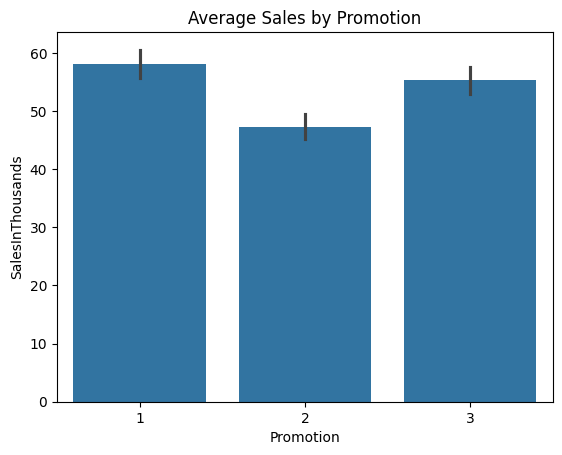

In [9]:
sns.barplot(data=df, x="Promotion", y="SalesInThousands")
plt.title("Average Sales by Promotion")
plt.show()

## Box Plot Analysis
We used a box plot to visualize the distribution of sales for each promotion.

This helps us understand the spread, median, and presence of outliers in the data.

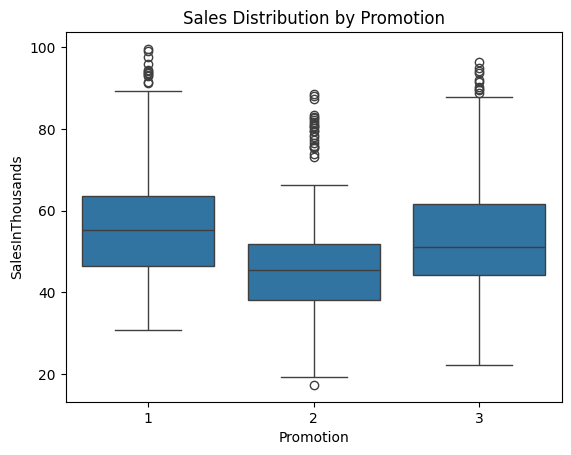

In [10]:
sns.boxplot(data=df, x="Promotion", y="SalesInThousands")
plt.title("Sales Distribution by Promotion")
plt.show()

## Weekly Trend Analysis
We analyzed how sales changed over time across different promotions.

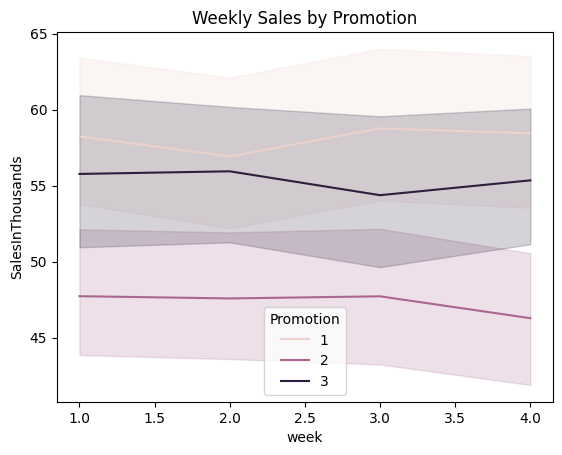

In [11]:
sns.lineplot(data=df, x="week", y="SalesInThousands", hue="Promotion")
plt.title("Weekly Sales by Promotion")
plt.show()

## Statistical Testing (ANOVA)
We use ANOVA to determine whether the differences between promotions are statistically significant.

In [12]:
from scipy.stats import f_oneway

p1 = df[df["Promotion"] == 1]["SalesInThousands"]
p2 = df[df["Promotion"] == 2]["SalesInThousands"]
p3 = df[df["Promotion"] == 3]["SalesInThousands"]

f_stat, p_value = f_oneway(p1, p2, p3)

print("P-value:", p_value)

P-value: 6.765849261408834e-10


## ANOVA Result Interpretation
The p-value is less than 0.05, which indicates that the differences between promotions are statistically significant.

This means the variation in sales is not due to random chance.

## Final Recommendation
Based on the analysis, Promotion 3 achieved the highest average sales.

The ANOVA test confirmed that the differences are statistically significant.

Therefore, Promotion 3 is the best marketing strategy.

## Summary
- Promotion 3 is the best
- Promotion 2 is the weakest
- Differences are statistically significant